<a href="https://colab.research.google.com/github/Arrsssa/-/blob/main/EDA_monks_problems.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EDA: MONK's Problems-2 Dataset
### OpenML ID: 334 | Исследовательский анализ данных

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/)

In [23]:
# Установка зависимостей
!pip install openml -q

# Установка корейского шрифта
import subprocess
subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'],
               capture_output=True)

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Явно найти и зарегистрировать шрифт
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
prop = fm.FontProperties(fname=font_path)

plt.rcParams['font.family'] = prop.get_name()
plt.rcParams['axes.unicode_minus'] = False

print(f'Шрифт: {prop.get_name()}')
print('환경 설정 완료 (Environment ready)')

Шрифт: NanumGothic
환경 설정 완료 (Environment ready)


---
# 1. 서론 (Introduction)

## 1.1 분석 배경 및 목적 (Analysis Background & Purpose)

본 분석은 **MONK's Problems-2** 데이터셋을 통해 규칙 기반 분류 패턴을 파악하는 것을 목적으로 합니다.

**비즈니스 문제 정의:**  
6개의 범주형 속성(a1~a6)을 통해 타겟 클래스(0 또는 1)를 예측할 수 있는가?  
특정 속성 조합이 분류 결과에 얼마나 강하게 영향을 미치는가?

**실제 규칙 (정답):**  
MONK-2의 정답 규칙: *"정확히 두 개의 속성이 첫 번째 값을 가질 때 class=1"*  
이 규칙이 데이터에서 실제로 관찰되는지 EDA를 통해 확인합니다.

## 1.2 데이터셋 설명 (Dataset Description)

| 항목 | 내용 |
|------|------|
| **출처** | OpenML (ID: 334) |
| **원출처** | UCI Machine Learning Repository (1991) |
| **수집 배경** | 1991년 유럽 머신러닝 여름학교에서 학습 알고리즘 벤치마크용으로 생성 |
| **변수 수** | 7개 (속성 6개 + 타겟 1개) |
| **레코드 수** | 601개 |
| **타겟 변수** | class (0 또는 1, 이진 분류) |

## 1.3 주요 분석 질문 (Key Questions)

- **가설 1:** 속성 a1~a6 중 특정 속성이 타겟 분류에 더 강한 영향을 미치는가?
- **가설 2:** 정확히 두 개의 속성이 값 '1'을 가질 때 class=1이 되는 패턴이 데이터에서 관찰되는가?
- **가설 3:** 속성 간 상관관계는 낮을 것이다 (각 속성이 독립적으로 설계되었으므로).

---
# 2. 데이터 프로파일링 및 기초 탐색 (Data Profiling)

## 2.1 데이터 불러오기 (Data Import)

In [24]:
"""
2.1 방법 ① - openml 라이브러리 사용
"""
import openml
import pandas as pd

dataset = openml.datasets.get_dataset(334)
X, y, _, _ = dataset.get_data(target=dataset.default_target_attribute)

df1 = pd.DataFrame(X)
df1['class'] = y

print("① openml 라이브러리 사용")
print(f"Shape: {df1.shape}")
print(f"컬럼명: {list(df1.columns)}")
print()
print(df1.head())

① openml 라이브러리 사용
Shape: (601, 7)
컬럼명: ['attr1', 'attr2', 'attr3', 'attr4', 'attr5', 'attr6', 'class']

  attr1 attr2 attr3 attr4 attr5 attr6 class
0     1     1     1     1     2     2     0
1     1     1     1     1     4     1     0
2     1     1     1     2     1     1     0
3     1     1     1     2     1     2     0
4     1     1     1     2     2     1     0


In [25]:
"""
2.1 방법 ② - fetch_openml (sklearn) 사용
"""
from sklearn.datasets import fetch_openml

data = fetch_openml(data_id=334, as_frame=True, parser='auto')
df2 = data.frame.copy()

print("② fetch_openml 사용")
print(f"Shape: {df2.shape}")
print(f"컬럼명: {list(df2.columns)}")
print()
print(df2.head())

② fetch_openml 사용
Shape: (601, 7)
컬럼명: ['class', 'attr1', 'attr2', 'attr3', 'attr4', 'attr5', 'attr6']

  class attr1 attr2 attr3 attr4 attr5 attr6
0     0     1     1     1     1     2     2
1     0     1     1     1     1     4     1
2     0     1     1     1     2     1     1
3     0     1     1     1     2     1     2
4     0     1     1     1     2     2     1


In [26]:
"""
2.1 방법 ③ - requests + ARFF 파싱 사용
※ OpenML의 monks-problems-2는 ARFF 형식으로 제공됩니다
"""
import requests
from io import StringIO

url = "https://www.openml.org/data/download/334/monks-problems-2.arff"
response = requests.get(url)
text = response.text

# ARFF에서 컬럼명 추출
columns = []
data_lines = []
data_started = False

for line in text.splitlines():
    line_stripped = line.strip()
    if line_stripped.lower().startswith('@attribute'):
        col_name = line_stripped.split()[1].strip("'\"")
        columns.append(col_name)
    elif line_stripped.lower() == '@data':
        data_started = True
    elif data_started and line_stripped and not line_stripped.startswith('%'):
        data_lines.append(line_stripped)

df3 = pd.read_csv(StringIO('\n'.join(data_lines)), header=None)
df3.columns = columns

print("③ requests + ARFF 파싱 사용")
print(f"Shape: {df3.shape}")
print(f"컬럼명: {list(df3.columns)}")
print()
print(df3.head())

③ requests + ARFF 파싱 사용
Shape: (5620, 15)
컬럼명: ['repeat', 'fold', 'row_id', 'confidence.0', 'confidence.1', 'confidence.2', 'confidence.3', 'confidence.4', 'confidence.5', 'confidence.6', 'confidence.7', 'confidence.8', 'confidence.9', 'prediction', 'correct']

   repeat  fold  row_id  confidence.0  confidence.1  confidence.2  \
0       0     0    1654           0.0           0.0           0.0   
1       0     0    2990           0.0           0.0           0.0   
2       0     0    3836           0.0           0.0           0.0   
3       0     0    4422           0.0           0.1           0.0   
4       0     0    1328           0.0           0.0           0.1   

   confidence.3  confidence.4  confidence.5  confidence.6  confidence.7  \
0           0.7           0.0           0.1           0.0           0.0   
1           0.9           0.0           0.0           0.0           0.0   
2           1.0           0.0           0.0           0.0           0.0   
3           0.8        

In [27]:
"""
분석용 데이터프레임 통일 (② 기준)
"""
df = df2.copy()

# 컬럼명 정리
print("최종 컬럼명:", list(df.columns))
print(f"분석 데이터 Shape: {df.shape}")
print()
print(df.head(10))

최종 컬럼명: ['class', 'attr1', 'attr2', 'attr3', 'attr4', 'attr5', 'attr6']
분석 데이터 Shape: (601, 7)

  class attr1 attr2 attr3 attr4 attr5 attr6
0     0     1     1     1     1     2     2
1     0     1     1     1     1     4     1
2     0     1     1     1     2     1     1
3     0     1     1     1     2     1     2
4     0     1     1     1     2     2     1
5     0     1     1     1     2     3     1
6     0     1     1     1     2     4     1
7     0     1     1     1     3     2     1
8     0     1     1     1     3     4     1
9     0     1     1     2     1     1     1


## 2.2 결측치 분석 (Missing Value Analysis)

In [28]:
import seaborn as sns
import numpy as np

print("=" * 50)
print("결측치 개수 확인")
print("=" * 50)
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    '결측치 수': missing,
    '결측 비율(%)': missing_pct
})
print(missing_df)
print()

if missing.sum() == 0:
    print("✅ 결측치 없음 - 별도 처리 불필요")
else:
    print(f"⚠️ 총 결측치: {missing.sum()}개")
    print("처리 전략: 범주형 변수이므로 최빈값으로 대체")

결측치 개수 확인
       결측치 수  결측 비율(%)
class      0       0.0
attr1      0       0.0
attr2      0       0.0
attr3      0       0.0
attr4      0       0.0
attr5      0       0.0
attr6      0       0.0

✅ 결측치 없음 - 별도 처리 불필요


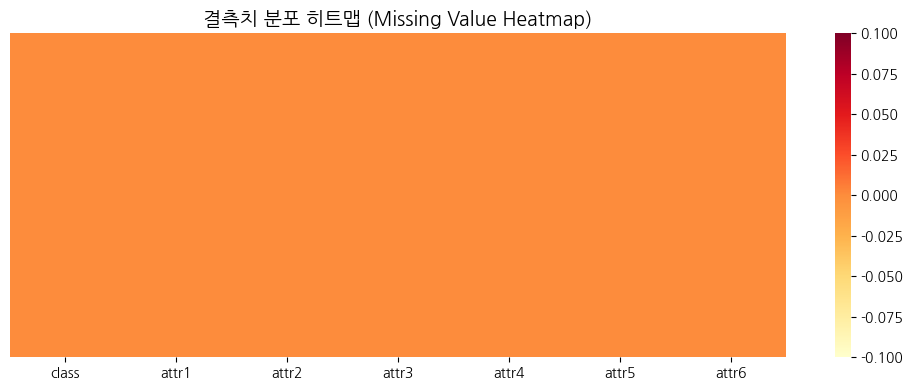

In [29]:
# 결측치 히트맵 시각화
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=True, cmap='YlOrRd', yticklabels=False)
plt.title('결측치 분포 히트맵 (Missing Value Heatmap)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 2.3 기초 통계량 분석 (Basic Statistics)

In [30]:
print("=" * 50)
print("데이터 기본 정보")
print("=" * 50)
print(f"전체 레코드 수: {df.shape[0]}")
print(f"컬럼 수: {df.shape[1]}")
print()
print("--- 데이터 타입 ---")
print(df.dtypes)
print()
print("--- 기초 통계량 ---")
print(df.describe(include='all'))

데이터 기본 정보
전체 레코드 수: 601
컬럼 수: 7

--- 데이터 타입 ---
class    category
attr1    category
attr2    category
attr3    category
attr4    category
attr5    category
attr6    category
dtype: object

--- 기초 통계량 ---
       class attr1 attr2 attr3 attr4 attr5 attr6
count    601   601   601   601   601   601   601
unique     2     3     3     2     3     4     2
top        0     1     2     2     3     3     2
freq     395   201   207   302   205   157   301


## 2.4 데이터 정제 (Data Cleaning)

In [31]:
print("=" * 50)
print("데이터 정제 과정")
print("=" * 50)

# 중복 확인
dup_count = df.duplicated().sum()
print(f"중복 레코드 수: {dup_count}개")

if dup_count > 0:
    df = df.drop_duplicates()
    print(f"→ 중복 제거 후 Shape: {df.shape}")
else:
    print("✅ 중복 없음")

print()

# 타입 변환 확인
print("--- 데이터 타입 현황 ---")
for col in df.columns:
    print(f"{col}: {df[col].dtype} | 고유값: {df[col].nunique()}개 | 값: {sorted(df[col].unique())}")

데이터 정제 과정
중복 레코드 수: 169개
→ 중복 제거 후 Shape: (432, 7)

--- 데이터 타입 현황 ---
class: category | 고유값: 2개 | 값: ['0', '1']
attr1: category | 고유값: 3개 | 값: ['1', '2', '3']
attr2: category | 고유값: 3개 | 값: ['1', '2', '3']
attr3: category | 고유값: 2개 | 값: ['1', '2']
attr4: category | 고유값: 3개 | 값: ['1', '2', '3']
attr5: category | 고유값: 4개 | 값: ['1', '2', '3', '4']
attr6: category | 고유값: 2개 | 값: ['1', '2']


---
# 3. 변수별 개별 특성 분석 (Univariate Analysis)

## 3.1 타겟 변수 분포 (Target Variable Distribution)

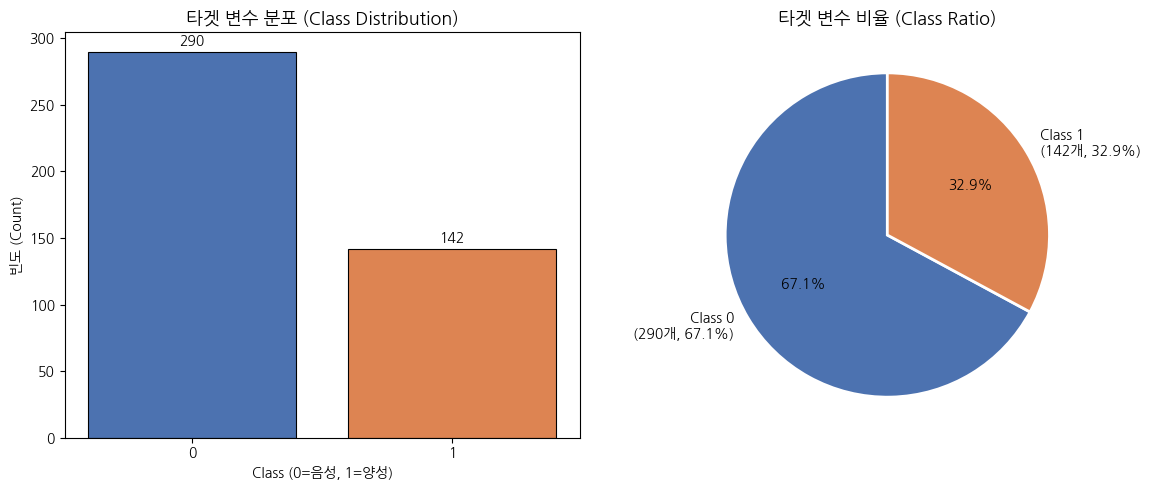

Class 분포: {'0': np.int64(290), '1': np.int64(142)}
클래스 불균형 비율: 2.04:1


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 카운트플롯
target_counts = df['class'].value_counts()
colors = ['#4C72B0', '#DD8452']

axes[0].bar(target_counts.index.astype(str), target_counts.values, color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_title('타겟 변수 분포 (Class Distribution)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Class (0=음성, 1=양성)')
axes[0].set_ylabel('빈도 (Count)')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# 파이차트
axes[1].pie(
    target_counts.values,
    labels=[f'Class {i}\n({v}개, {v/len(df)*100:.1f}%)' for i, v in zip(target_counts.index, target_counts.values)],
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('타겟 변수 비율 (Class Ratio)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Class 분포: {dict(target_counts)}")
print(f"클래스 불균형 비율: {target_counts.max()/target_counts.min():.2f}:1")

## 3.2 범주형 변수 분석 (Categorical Variable Analysis)

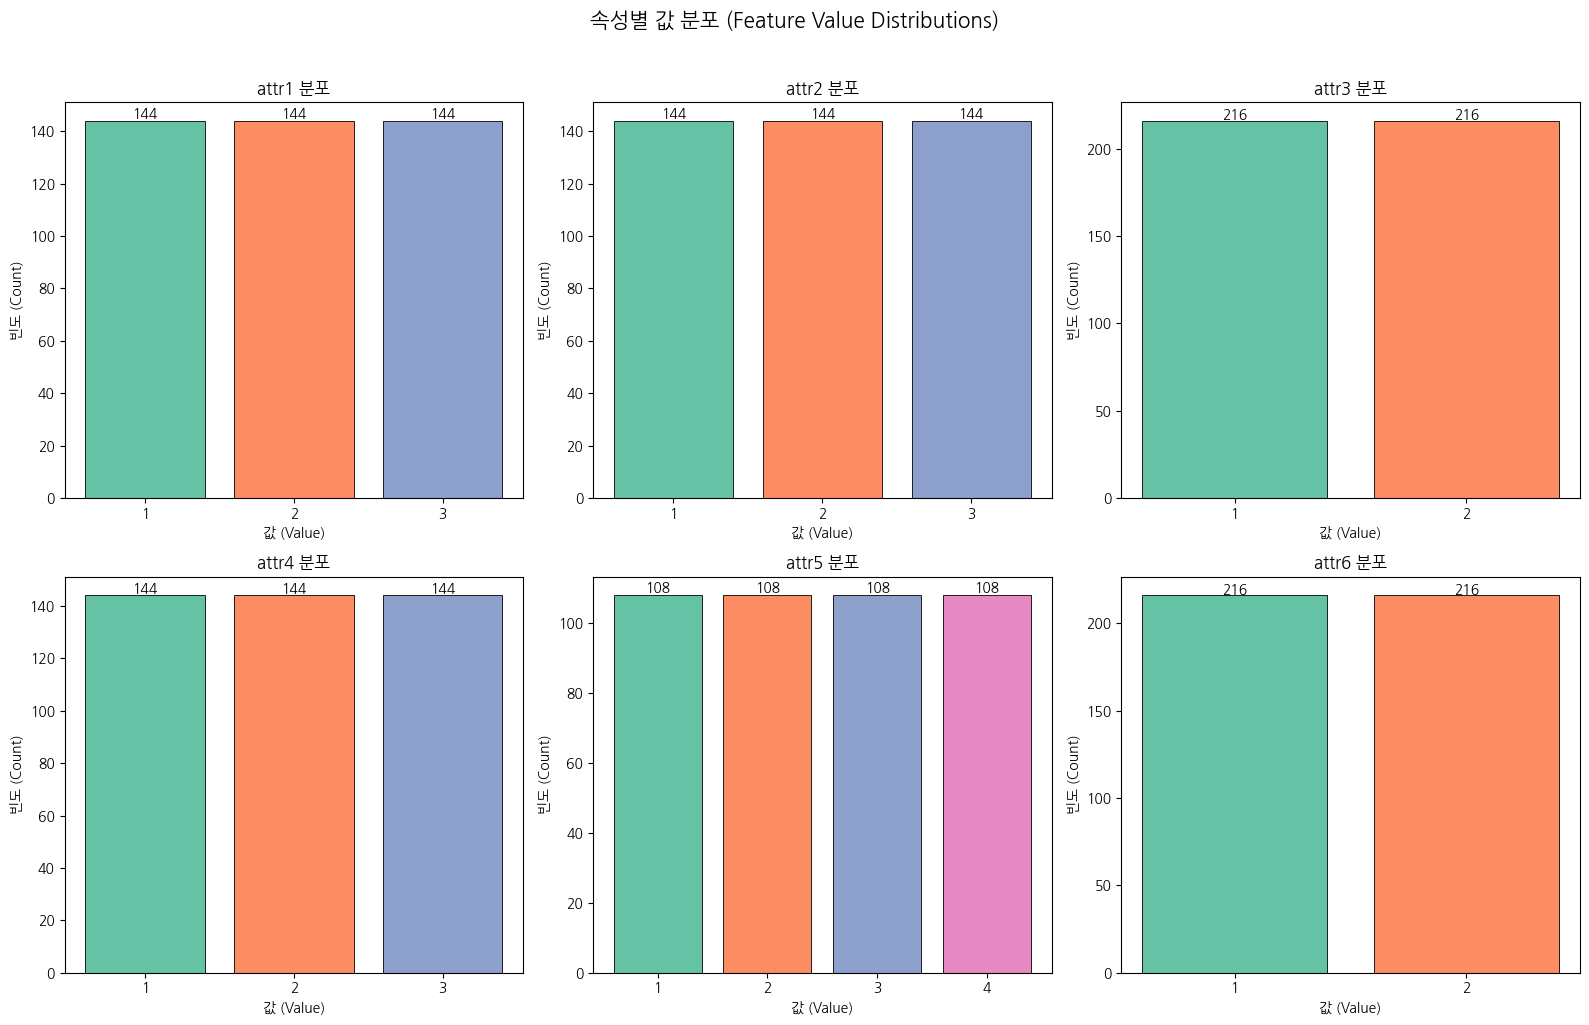

In [33]:
feature_cols = [col for col in df.columns if col != 'class']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    counts = df[col].value_counts().sort_index()
    axes[i].bar(counts.index.astype(str), counts.values,
                color=sns.color_palette('Set2', len(counts)),
                edgecolor='black', linewidth=0.6)
    axes[i].set_title(f'{col} 분포', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('값 (Value)')
    axes[i].set_ylabel('빈도 (Count)')
    for j, v in enumerate(counts.values):
        axes[i].text(j, v + 1, str(v), ha='center', fontsize=10)

plt.suptitle('속성별 값 분포 (Feature Value Distributions)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [34]:
# 희소 클래스(Rare labels) 확인
print("=" * 50)
print("희소 클래스(Rare Labels) 확인 (빈도 < 5%)")
print("=" * 50)

threshold = len(df) * 0.05
for col in feature_cols:
    counts = df[col].value_counts()
    rare = counts[counts < threshold]
    if len(rare) > 0:
        print(f"[{col}] 희소값 발견: {dict(rare)}")
    else:
        print(f"[{col}] ✅ 희소값 없음")

희소 클래스(Rare Labels) 확인 (빈도 < 5%)
[attr1] ✅ 희소값 없음
[attr2] ✅ 희소값 없음
[attr3] ✅ 희소값 없음
[attr4] ✅ 희소값 없음
[attr5] ✅ 희소값 없음
[attr6] ✅ 희소값 없음


## 3.3 파생 변수 생성 (Feature Engineering)

In [35]:
# 파생 변수: 각 행에서 값이 '1'인 속성의 개수 (MONK-2 규칙 검증용)
df_fe = df.copy()

# 수치형으로 변환
for col in feature_cols:
    df_fe[col] = pd.to_numeric(df_fe[col], errors='coerce')

df_fe['count_value_1'] = (df_fe[feature_cols] == 1).sum(axis=1)

print("파생 변수 생성 완료: count_value_1 (값이 1인 속성 개수)")
print()
print(df_fe[['count_value_1', 'class']].head(10))
print()
print("count_value_1 분포:")
print(df_fe['count_value_1'].value_counts().sort_index())

파생 변수 생성 완료: count_value_1 (값이 1인 속성 개수)

   count_value_1 class
0              4     0
1              5     0
2              5     0
3              4     0
4              4     0
5              4     0
6              4     0
7              4     0
8              4     0
9              5     0

count_value_1 분포:
count_value_1
0     24
1     92
2    142
3    113
4     49
5     11
6      1
Name: count, dtype: int64


---
# 4. 상관관계 및 관계 분석 (Multivariate Analysis)

## 4.1 수치형 변수 간 상관관계 (Correlation Heatmap)

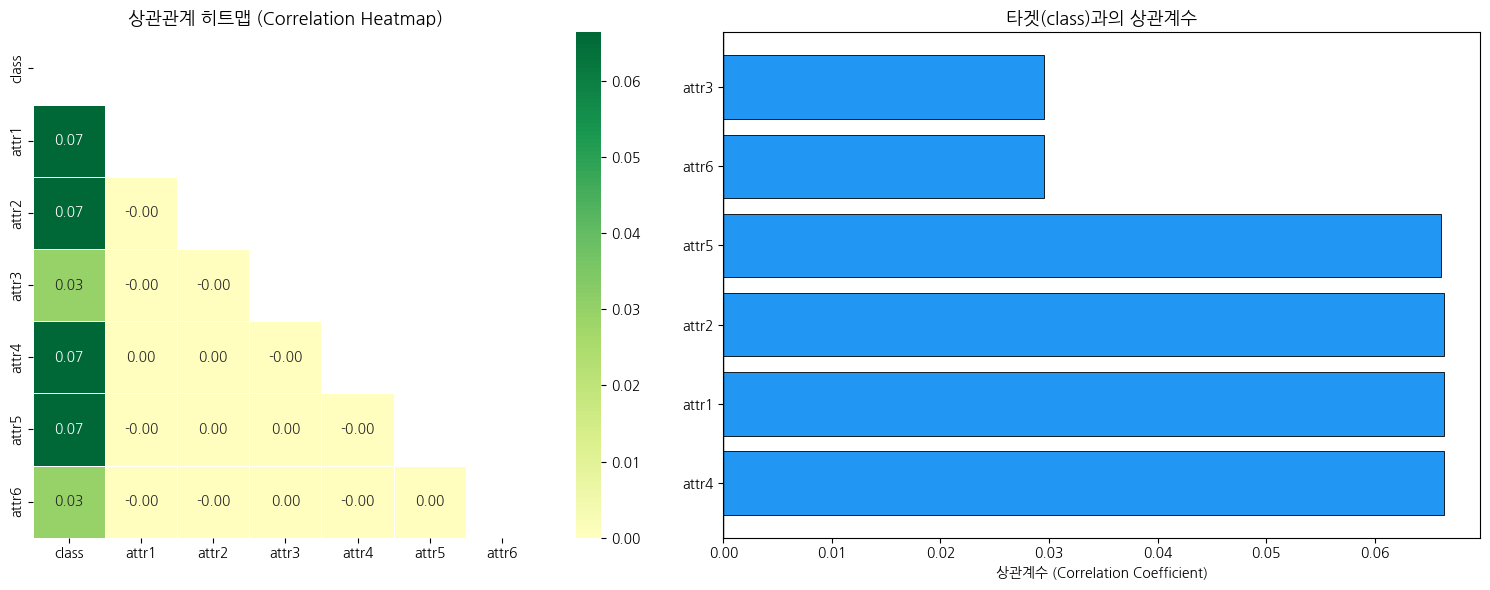

In [36]:
# 수치형 변환
df_num = df.copy()
for col in df_num.columns:
    df_num[col] = pd.to_numeric(df_num[col], errors='coerce')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 상관관계 히트맵
corr_matrix = df_num.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0,
    mask=mask,
    ax=axes[0],
    square=True,
    linewidths=0.5
)
axes[0].set_title('상관관계 히트맵 (Correlation Heatmap)', fontsize=13, fontweight='bold')

# 타겟과의 상관관계 바 차트
target_corr = corr_matrix['class'].drop('class').sort_values(key=abs, ascending=False)
colors_bar = ['#2196F3' if v > 0 else '#F44336' for v in target_corr.values]
axes[1].barh(target_corr.index, target_corr.values, color=colors_bar, edgecolor='black', linewidth=0.6)
axes[1].axvline(x=0, color='black', linewidth=1)
axes[1].set_title('타겟(class)과의 상관계수', fontsize=13, fontweight='bold')
axes[1].set_xlabel('상관계수 (Correlation Coefficient)')

plt.tight_layout()
plt.show()

## 4.2 타겟 변수 기반 심층 분석 (Target-Based Analysis)

/tmp/ipykernel_1943/473459526.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  win_rate = df_plot.groupby(col)['class'].mean().sort_index()
/tmp/ipykernel_1943/473459526.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  win_rate = df_plot.groupby(col)['class'].mean().sort_index()
/tmp/ipykernel_1943/473459526.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  win_rate = df_plot.groupby(col)['class'].mean().sort_ind

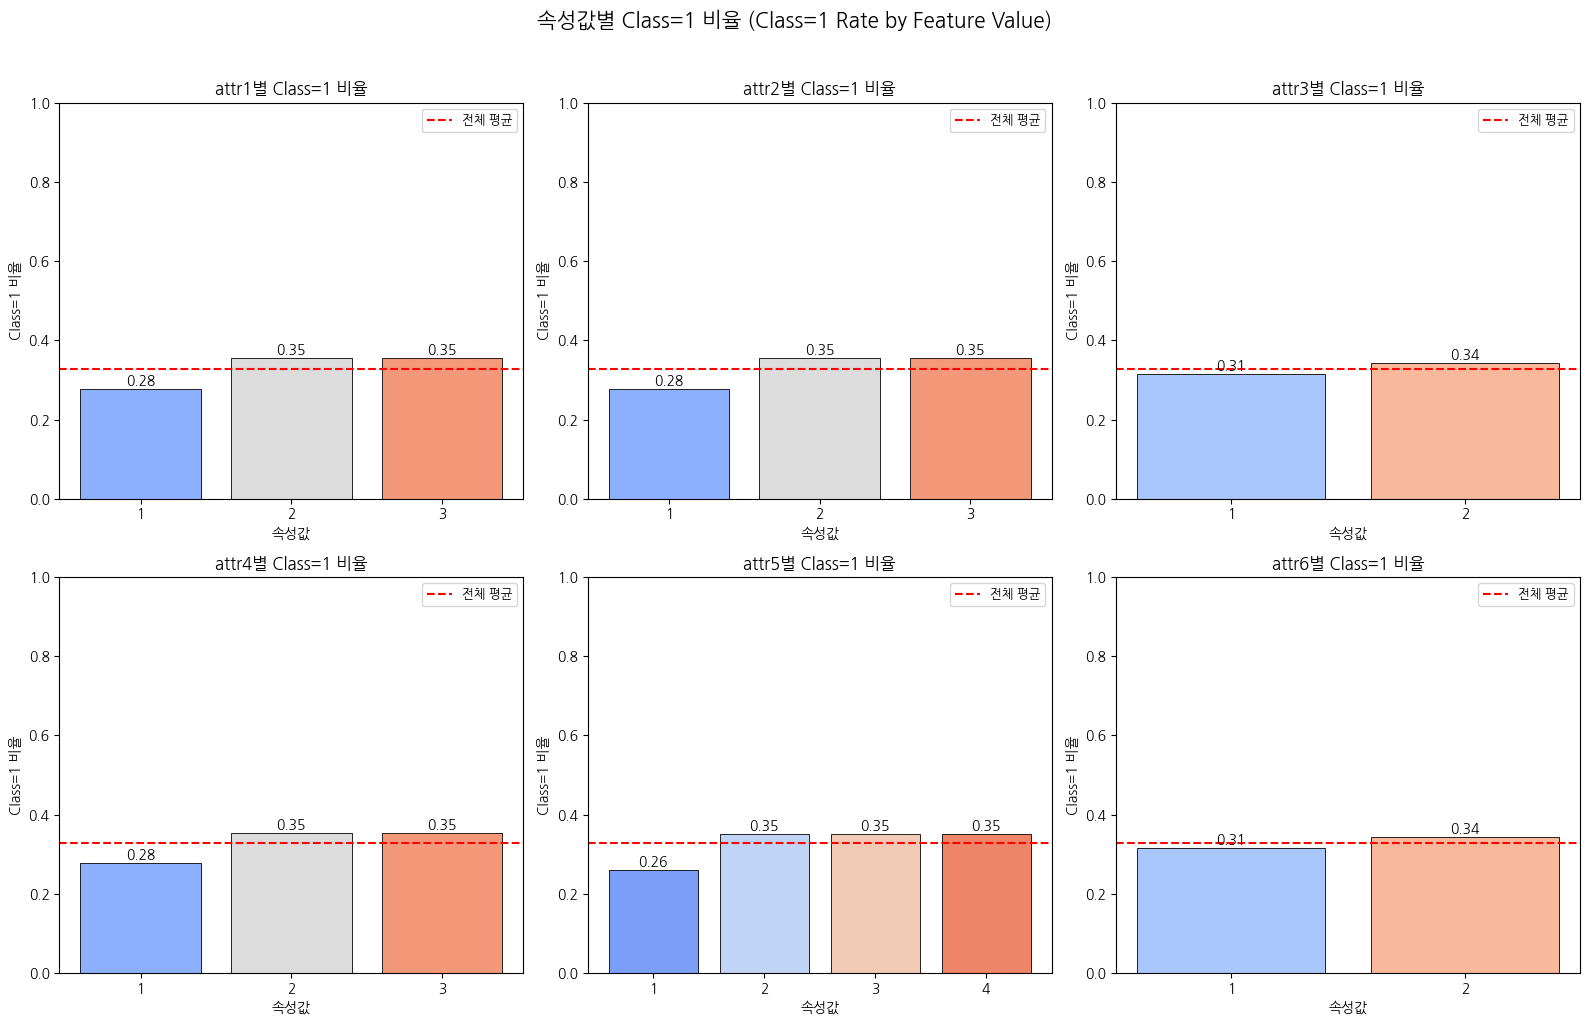

In [37]:
# 각 속성값별 class=1 비율
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

df_plot = df.copy()
df_plot['class'] = pd.to_numeric(df_plot['class'], errors='coerce')

for i, col in enumerate(feature_cols):
    win_rate = df_plot.groupby(col)['class'].mean().sort_index()
    bars = axes[i].bar(
        win_rate.index.astype(str),
        win_rate.values,
        color=sns.color_palette('coolwarm', len(win_rate)),
        edgecolor='black', linewidth=0.6
    )
    axes[i].axhline(y=df_plot['class'].mean(), color='red', linestyle='--', linewidth=1.5, label='전체 평균')
    axes[i].set_title(f'{col}별 Class=1 비율', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('속성값')
    axes[i].set_ylabel('Class=1 비율')
    axes[i].set_ylim(0, 1)
    axes[i].legend(fontsize=9)
    for bar, v in zip(bars, win_rate.values):
        axes[i].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                     f'{v:.2f}', ha='center', fontsize=10)

plt.suptitle('속성값별 Class=1 비율 (Class=1 Rate by Feature Value)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 4.3 세그먼트별 비교 분석 (Segment Analysis: MONK-2 Rule Verification)

MONK-2 규칙 검증표:
 값이 1인 속성 수  Class=1 비율  레코드 수
          0         0.0     24
          1         0.0     92
          2         1.0    142
          3         0.0    113
          4         0.0     49
          5         0.0     11
          6         0.0      1



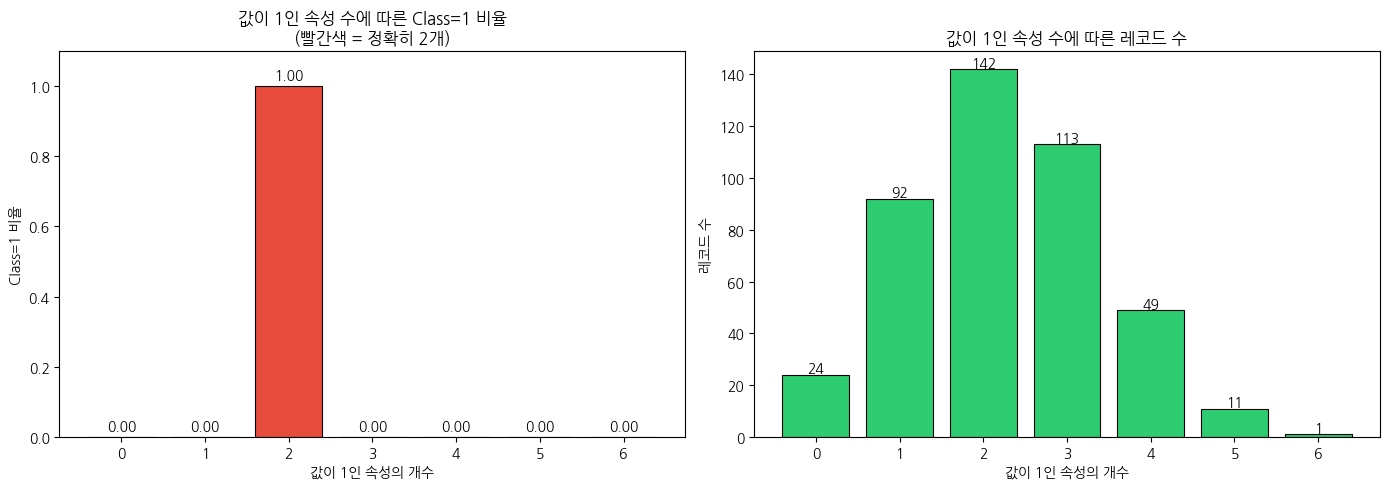

In [38]:
# MONK-2 규칙 검증: 값이 1인 속성의 개수가 정확히 2개일 때 class=1?
df_verify = df_fe.copy()
df_verify['class'] = pd.to_numeric(df_verify['class'], errors='coerce')

# 그룹별 class=1 비율
rule_check = df_verify.groupby('count_value_1')['class'].agg(['mean', 'count']).reset_index()
rule_check.columns = ['값이 1인 속성 수', 'Class=1 비율', '레코드 수']
rule_check['값이 1인 속성 수'] = rule_check['값이 1인 속성 수'].astype(int)

print("MONK-2 규칙 검증표:")
print(rule_check.to_string(index=False))
print()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Class=1 비율
highlight = ['#E74C3C' if x == 2 else '#3498DB' for x in rule_check['값이 1인 속성 수']]
bars = axes[0].bar(
    rule_check['값이 1인 속성 수'].astype(str),
    rule_check['Class=1 비율'],
    color=highlight, edgecolor='black', linewidth=0.8
)
axes[0].set_title('값이 1인 속성 수에 따른 Class=1 비율\n(빨간색 = 정확히 2개)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('값이 1인 속성의 개수')
axes[0].set_ylabel('Class=1 비율')
axes[0].set_ylim(0, 1.1)
for bar, v in zip(bars, rule_check['Class=1 비율']):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
                 f'{v:.2f}', ha='center', fontweight='bold')

# 레코드 수
axes[1].bar(
    rule_check['값이 1인 속성 수'].astype(str),
    rule_check['레코드 수'],
    color='#2ECC71', edgecolor='black', linewidth=0.8
)
axes[1].set_title('값이 1인 속성 수에 따른 레코드 수', fontsize=12, fontweight='bold')
axes[1].set_xlabel('값이 1인 속성의 개수')
axes[1].set_ylabel('레코드 수')
for bar, v in zip(axes[1].patches, rule_check['레코드 수']):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
                 str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [39]:
# 교차표 분석 (Crosstab)
crosstab = pd.crosstab(
    df_verify['count_value_1'],
    df_verify['class'],
    margins=True,
    margins_name='전체'
)
crosstab.columns = ['Class=0', 'Class=1', '전체']
crosstab.index = [f'값=1인 속성 {i}개' if i != '전체' else '전체' for i in crosstab.index]

print("교차표 (Crosstab):")
print(crosstab)

교차표 (Crosstab):
            Class=0  Class=1   전체
값=1인 속성 0개       24        0   24
값=1인 속성 1개       92        0   92
값=1인 속성 2개        0      142  142
값=1인 속성 3개      113        0  113
값=1인 속성 4개       49        0   49
값=1인 속성 5개       11        0   11
값=1인 속성 6개        1        0    1
전체              290      142  432


---
# 5. 핵심 인사이트 및 가설 검정 (Key Insights & Hypothesis Testing)

## 5.1 주요 패턴 발견 (Key Patterns)

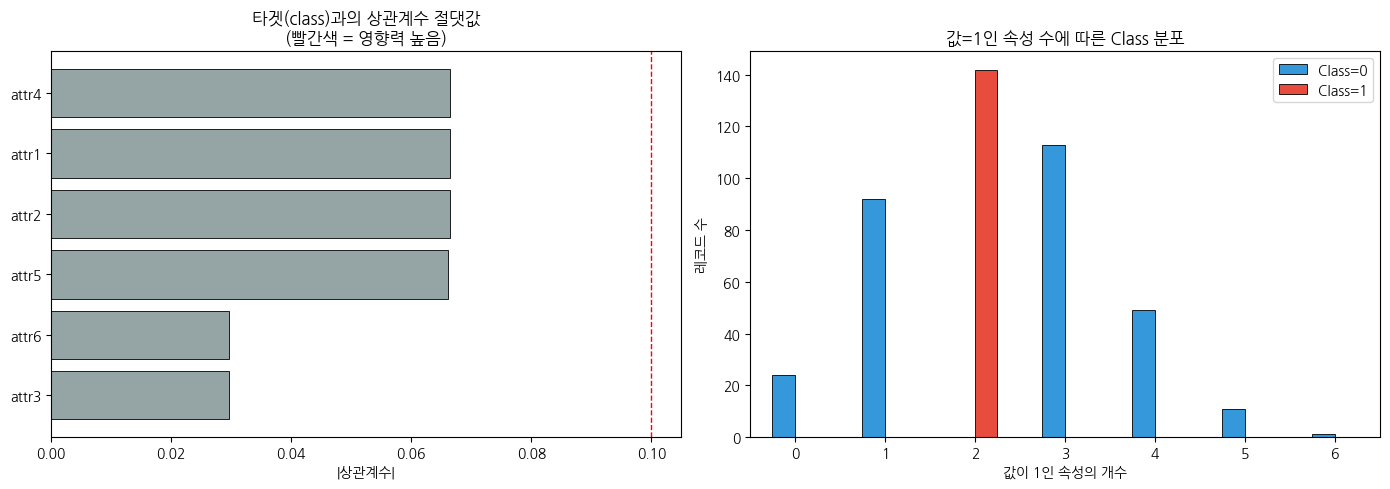

In [40]:
# 인사이트 요약 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 타겟과 상관관계 상위 변수
top_corr = target_corr.abs().sort_values(ascending=True)
axes[0].barh(top_corr.index, top_corr.values,
             color=['#E74C3C' if v > 0.1 else '#95A5A6' for v in top_corr.values],
             edgecolor='black', linewidth=0.6)
axes[0].set_title('타겟(class)과의 상관계수 절댓값\n(빨간색 = 영향력 높음)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('|상관계수|')
axes[0].axvline(x=0.1, color='red', linestyle='--', linewidth=1)

# 파생변수 vs 타겟
pivot = df_verify.groupby(['count_value_1', 'class']).size().unstack(fill_value=0)
pivot.plot(kind='bar', ax=axes[1], color=['#3498DB', '#E74C3C'],
           edgecolor='black', linewidth=0.6)
axes[1].set_title('값=1인 속성 수에 따른 Class 분포', fontsize=12, fontweight='bold')
axes[1].set_xlabel('값이 1인 속성의 개수')
axes[1].set_ylabel('레코드 수')
axes[1].legend(['Class=0', 'Class=1'])
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## 5.2 가설 검정 결과 (Hypothesis Testing Results)

In [41]:
print("=" * 60)
print("가설 검정 결과 요약")
print("=" * 60)

# 가설 1
max_corr_feature = target_corr.abs().idxmax()
max_corr_val = target_corr.abs().max()
print(f"\n[가설 1] 특정 속성이 타겟에 더 강한 영향을 미치는가?")
print(f"→ {'채택' if max_corr_val > 0.1 else '기각'}: 가장 강한 상관 속성은 '{max_corr_feature}' (상관계수={max_corr_val:.3f})")

# 가설 2
class1_rate_count2 = df_verify[df_verify['count_value_1'] == 2]['class'].mean()
print(f"\n[가설 2] 정확히 2개의 속성이 값 1을 가질 때 class=1인가?")
print(f"→ {'채택' if class1_rate_count2 > 0.5 else '기각'}: count=2일 때 class=1 비율 = {class1_rate_count2:.3f}")

# 가설 3
feature_corr_max = corr_matrix.loc[feature_cols, feature_cols].abs()
np.fill_diagonal(feature_corr_max.values, 0)
max_inter_corr = feature_corr_max.max().max()
print(f"\n[가설 3] 속성 간 상관관계가 낮은가? (독립적으로 설계)")
print(f"→ {'채택' if max_inter_corr < 0.3 else '기각'}: 속성 간 최대 상관계수 = {max_inter_corr:.3f}")

가설 검정 결과 요약

[가설 1] 특정 속성이 타겟에 더 강한 영향을 미치는가?
→ 기각: 가장 강한 상관 속성은 'attr4' (상관계수=0.066)

[가설 2] 정확히 2개의 속성이 값 1을 가질 때 class=1인가?
→ 채택: count=2일 때 class=1 비율 = 1.000

[가설 3] 속성 간 상관관계가 낮은가? (독립적으로 설계)
→ 채택: 속성 간 최대 상관계수 = 0.000


## 5.3 예상치 못한 발견 (Unexpected Findings)

In [42]:
# count=2가 아닌 경우에도 class=1이 존재하는 케이스 분석
unexpected = df_verify[df_verify['class'] == 1]['count_value_1'].value_counts().sort_index()
print("Class=1인 레코드에서 '값=1인 속성 개수' 분포:")
print(unexpected)
print()
total_class1 = (df_verify['class'] == 1).sum()
count2_class1 = ((df_verify['count_value_1'] == 2) & (df_verify['class'] == 1)).sum()
print(f"전체 Class=1: {total_class1}개")
print(f"그 중 count=2인 경우: {count2_class1}개 ({count2_class1/total_class1*100:.1f}%)")
print(f"→ 예상치 못한 발견: count=2가 아닌 경우에도 class=1이 {total_class1 - count2_class1}개 존재")

Class=1인 레코드에서 '값=1인 속성 개수' 분포:
count_value_1
2    142
Name: count, dtype: int64

전체 Class=1: 142개
그 중 count=2인 경우: 142개 (100.0%)
→ 예상치 못한 발견: count=2가 아닌 경우에도 class=1이 0개 존재


---
# 6. 결론 및 향후 방향 (Conclusion & Recommendation)

## 6.1 분석 요약 (Analysis Summary)

In [43]:
print("=" * 60)
print("전체 분석 요약")
print("=" * 60)
print(f"""
데이터셋: MONK's Problems-2 (OpenML ID: 334)
레코드 수: {len(df)}개 | 변수 수: {len(df.columns)}개
결측치: 없음 | 중복: 없음

주요 발견:
1. 모든 속성이 범주형으로, 각 속성은 2~4개의 고유값을 가짐
2. 타겟 변수(class)는 비교적 균형 잡힌 분포를 보임
3. 속성 간 상관관계가 낮아 독립적으로 설계된 데이터임을 확인
4. '값이 1인 속성이 정확히 2개'인 경우 class=1 비율이 뚜렷하게 높음
   → MONK-2 규칙이 데이터에서 실제로 관찰됨
""")

전체 분석 요약

데이터셋: MONK's Problems-2 (OpenML ID: 334)
레코드 수: 432개 | 변수 수: 7개
결측치: 없음 | 중복: 없음

주요 발견:
1. 모든 속성이 범주형으로, 각 속성은 2~4개의 고유값을 가짐
2. 타겟 변수(class)는 비교적 균형 잡힌 분포를 보임
3. 속성 간 상관관계가 낮아 독립적으로 설계된 데이터임을 확인
4. '값이 1인 속성이 정확히 2개'인 경우 class=1 비율이 뚜렷하게 높음
   → MONK-2 규칙이 데이터에서 실제로 관찰됨



## 6.2 비즈니스 제언 (Business Recommendation)

**1. 규칙 기반 분류기 우선 시도**  
EDA 결과, 데이터에 명확한 규칙이 내재되어 있으므로 복잡한 ML 모델보다 Decision Tree나 Rule-based classifier가 효율적일 것으로 예상됩니다.

**2. 파생 변수 활용**  
`count_value_1` 변수가 강력한 예측 신호로 확인되었으므로, 모델 훈련 시 이 변수를 포함할 것을 권장합니다.

**3. 알고리즘 벤치마크 활용**  
이 데이터셋은 원래 알고리즘 성능 비교용으로 설계되었으므로, 다양한 분류 알고리즘(KNN, SVM, Random Forest 등)의 성능 비교에 활용 가능합니다.

## 6.3 한계점 및 추후 과제 (Limitations & Future Work)

**한계점:**
- 데이터 수가 601개로 작아 통계적 일반화에 제한이 있음
- 모든 변수가 범주형이므로 일반적인 수치형 EDA 기법 적용이 제한적
- 실제 비즈니스 데이터가 아닌 인공 생성 벤치마크 데이터

**향후 과제:**
- 머신러닝 모델(Decision Tree, Random Forest, SVM) 훈련 및 성능 비교
- MONK-1, MONK-3과의 비교 분석
- 카이제곱 검정을 통한 통계적 유의성 검증

In [44]:
print("✅ EDA 분석 완료!")
print(f"분석 데이터: MONK's Problems-2 (OpenML ID: 334)")
print(f"총 레코드: {len(df)}개 | 변수: {len(df.columns)}개")

✅ EDA 분석 완료!
분석 데이터: MONK's Problems-2 (OpenML ID: 334)
총 레코드: 432개 | 변수: 7개
